First, import dependencies.

In [1]:
from bs4 import BeautifulSoup
from cartopy import config
from dotenv import load_dotenv
from sodapy import Socrata

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import os 
import pandas as pd
import requests

Next, load API secrets from `.env` file.

In [2]:
load_dotenv() 

APP_TOKEN = os.environ['SOCRATA_APP_TOKEN']
APP_SECRET = os.environ['SOCRATA_APP_SECRET']

Create the Socrata client.

In [3]:
client = Socrata("data.seattle.gov", APP_TOKEN)

Let's fetch some data!

In [4]:
data = client.get("kzjm-xkqj", limit = 100)

Let's see what fields exist in each row...

In [5]:
data[0]

{'address': '11616 Aurora Ave N',
 'type': 'Aid Response',
 'datetime': '2026-02-10T14:35:00.000',
 'latitude': '47.713757',
 'longitude': '-122.344836',
 'report_location': {'type': 'Point', 'coordinates': [-122.344836, 47.713757]},
 'incident_number': 'F260019386',
 ':@computed_region_ru88_fbhk': '46',
 ':@computed_region_2day_rhn5': '123',
 ':@computed_region_cyqu_gs94': '1',
 ':@computed_region_kuhn_3gp2': '33',
 ':@computed_region_q256_3sug': '19582'}

In [6]:
df = pd.DataFrame.from_records(data)
df

,address,type,datetime,latitude,longitude,report_location,incident_number,:@computed_region_ru88_fbhk,:@computed_region_2day_rhn5,:@computed_region_cyqu_gs94,:@computed_region_kuhn_3gp2,:@computed_region_q256_3sug
0,11616 Aurora Ave N,Aid Response,2026-02-10T14:35:00.000,47.713757,-122.344836,"{'type': 'Point', 'coordinates': [-122.344836,...",F260019386,46,123,1,33,19582
1,7125 Fauntleroy Way Sw,Aid Response,2026-02-10T14:34:00.000,47.539419,-122.390816,"{'type': 'Point', 'coordinates': [-122.390816,...",F260019385,37,NaN,NaN,51,17916
2,4915 25th Ave Ne,Medic Response,2026-02-10T14:33:00.000,47.664451,-122.300909,"{'type': 'Point', 'coordinates': [-122.300909,...",F260019384,53,NaN,NaN,48,18383
3,12201 Aurora Ave N,Aid Response,2026-02-10T14:29:00.000,47.717783,-122.344906,"{'type': 'Point', 'coordinates': [-122.344906,...",F260019383,46,123,1,33,19582
4,6TH AVE / JAMES ST,Aid Response,2026-02-10T14:28:00.000,47.604161,-122.328079,"{'type': 'Point', 'coordinates': [-122.328079,...",F260019382,14,NaN,NaN,19,18379
...,...,...,...,...,...,...,...,...,...,...,...,...
95,11030 5th Ave Ne,Medic Response,2026-02-10T09:14:00.000,47.709488,-122.323301,"{'type': 'Point', 'coordinates': [-122.323301,...",F260019257,46,NaN,NaN,28,19579
96,N 46th St / Stone Ave N,Aid Response,2026-02-10T09:06:00.000,47.662125,-122.342115,"{'type': 'Point', 'coordinates': [-122.342115,...",F260019254,61,NaN,NaN,3,18377
97,1014 Boylston Ave,Aid Response,2026-02-10T09:05:00.000,47.610825,-122.321896,"{'type': 'Point', 'coordinates': [-122.321896,...",F260019253,8,NaN,NaN,12,18379
98,15th Ave Nw / Nw Market St,Illegal Burn,2026-02-10T09:03:00.000,47.668667,-122.376214,"{'type': 'Point', 'coordinates': [-122.376214,...",F260019250,4,NaN,NaN,1,18386


Can we iterate over the rows and plot the points on a map?

In [7]:
float(df["latitude"].min())

47.522726

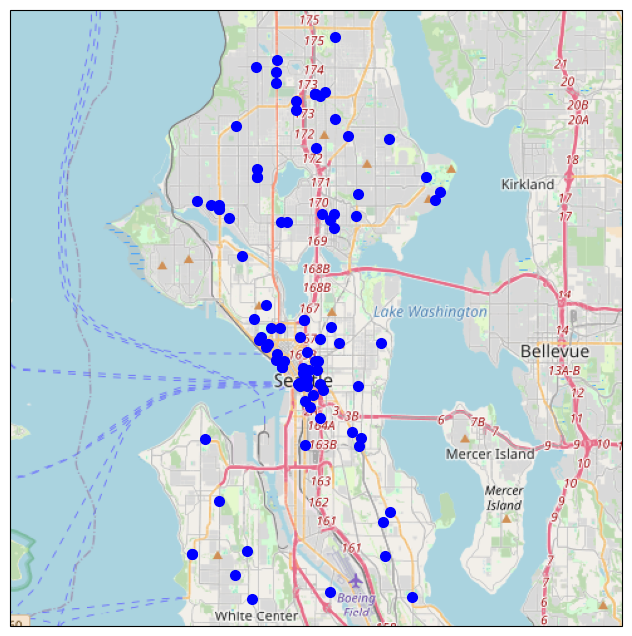

In [8]:
padding = 0.01
lon_min, lon_max = float(df["longitude"].min()) + padding * 10, float(df["longitude"].max()) - padding * 10
lat_min, lat_max = float(df["latitude"].min()) - padding, float(df["latitude"].max()) + padding

osm_tiles = cimgt.OSM()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': osm_tiles.crs})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.add_image(osm_tiles, 11)

for datum in data:
    ax.plot(
        float(datum['longitude']), 
        float(datum['latitude']), 
        'bo', markersize=7, transform=ccrs.Geodetic()
    )

plt.show()

Neat! Now, SFD live (sfdlive.com) has "richer" data than we have. They actually know which units were assigned to which event. Would it be possible for us to create a map of events that a specific unit responds to? And perhaps plot the route most likely taken between each event? To get an estimated sense of how far each unit drives every hour? That would be an interesting question to ask of the available data and one that could perhaps be useful for shift scheduling?

I've asked the owner of the website about what data source he uses. Perhaps I can try scraping his website for unit data? I note that you can query the website for a particular incident ID. `https://sfdlive.com/?id=F260019374` The resulting web page shows unit assignments. Can I do this with Python using the `requests` library?

In [9]:
incident_id = data[0]['incident_number']
incident_id

'F260019386'

In [10]:
sfd_url_template = "https://sfdlive.com/?id={}"
incident_url = sfd_url_template.format(incident_id)
incident_url

'https://sfdlive.com/?id=F260019386'

In [11]:
response = requests.get(incident_url)
response

<Response [200]>

We'll use BeautifulSoup to parse the HTML contents in the response.

In [12]:
soup = BeautifulSoup(response.content, 'html.parser')

I need to extract a `span` with `class="span-units-dispatched"`

In [13]:
soup.find_all("span", class_="span-units-dispatched")

[]

Hmmm... the response does not contain the `span` I'm looking for. It seems SFDLive has JavaScript code which needs to be run by a web browser. That JavaScript code is responsible for actually fetching and displaying the data, including creating the `span` I want. I have a couple of options here.

1. I could simulate the browser using Playwright, but this will be slow for lots of data...

In [17]:
from playwright.sync_api import sync_playwright

incident_url = 'https://sfdlive.com/?id=F260019386'

with sync_playwright() as p:
    browser = p.chromium.launch()
    page = browser.new_page()
    page.goto(incident_url)
    element = page.wait_for_selector(".span-units-dispatched")
    print(element.text_content())
    browser.close()

Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

2. I could attempt to reverse engineer the obfuscated JavaScript to see how it fetches the data and try directly fetching that way!

In [16]:
poll_url = "https://sfdlive.com/api/data/poll/" + incident_id
response = requests.get(poll_url)
response.content

b'{"error":"Unauthorized Request"}'